In [3]:
import kagglehub
from torch.utils.data import random_split

# Download latest version
path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")

print("Path to dataset files:", path)

100%|██████████| 481M/481M [00:33<00:00, 15.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1


In [4]:
from torchvision import datasets, transforms
import os
import re # Import regex for parsing filenames
from torch.utils.data import Dataset
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        # First pass to collect all unique class names from filenames
        unique_class_names = set()
        for img_name in os.listdir(root_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                match = re.match(r'^([a-zA-Z]+)', img_name)
                if match:
                    class_name = match.group(1).lower()
                    unique_class_names.add(class_name)

        self.idx_to_class = sorted(list(unique_class_names))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.idx_to_class)}

        # Second pass to populate image_paths and labels
        for img_name in os.listdir(root_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                img_path = os.path.join(root_dir, img_name)
                match = re.match(r'^([a-zA-Z]+)', img_name)
                if match:
                    class_name = match.group(1).lower()
                    if class_name in self.class_to_idx:
                        self.image_paths.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])

        if not self.image_paths:
            raise RuntimeError(f"Found 0 images or could not parse any class names in: {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Define paths to the actual train, valid, and test directories based on file system inspection
train_dir = os.path.join(path, 'train', 'images')
valid_dir = os.path.join(path, 'valid', 'images')
test_dir = os.path.join(path, 'test', 'images')

# --- Debugging: List contents of train_dir ---
print(f"Contents of train_dir ({train_dir}):")
print(os.listdir(train_dir))
# ---------------------------------------------

# Create CustomImageDataset for each split
train_dataset = CustomImageDataset(root_dir=train_dir, transform=transform)
valid_dataset = CustomImageDataset(root_dir=valid_dir, transform=transform)
test_dataset = CustomImageDataset(root_dir=test_dir, transform=transform)

# Extract correct class names and number of classes from the training dataset
class_names = train_dataset.idx_to_class # Use idx_to_class from custom dataset
num_classes = len(class_names)

print("Actual Garbage Classes (for training):", class_names)
print("Number of actual classes:", num_classes)

# Note: The visualization cell (3xj4uUwUDAnK) that used a 'dataset' variable
# with incorrect class labels will no longer work after this change.

Contents of train_dir (/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/train/images):
['paper405_jpg.rf.71244efa8263be5354066404e387063a_dup0.jpg', 'plastic48_jpg.rf.28b5d34ef09d7064e38b713669cc6a95.jpg', 'metal838_jpg.rf.5cafdaa07418fb88207e101e454f3fd8.jpg', 'biodegradable646_jpg.rf.de537855de7e1b534c51113130f734b3.jpg', 'paper1918_jpg.rf.233fba1562a51ca4b612349dffe837b8.jpg', 'metal486_jpg.rf.a72d1ca4d7668f05419ea086186967ef.jpg', 'glass2467_jpg.rf.c62d678082081c1a785cbd28cc6e0527.jpg', 'plastic77_jpg.rf.da664add7f95ad509ae62c0588adebf9_dup1.jpg', 'plastic267_jpg.rf.4bf0ecefb32b3686b7d3bde790181e29.jpg', 'biodegradable953_jpg.rf.dfef9dceac012bf6e1d7a5ac04b5244f.jpg', 'glass390_jpg.rf.710495dc8605cdd323357e4d2721989c.jpg', 'cardboard817_jpg.rf.854086889985e0b5f3eae0faaeb72cc1.jpg', 'biodegradable1907_jpeg.rf.9fa1d9c97ea2bf9da44a5b6c27327494.jpg', 'plastic8_jpg.rf.fa189087543f7948984838492bdcebac_dup1.jpg', 'plastic234_jpg.rf.7e6799d1332d7ef1ab59f5b2

In [5]:
import os
print(os.listdir(path))
for root, dirs, files in os.walk(path):
    print(root)
    for d in dirs:
        print(os.path.join(root, d))
    for f in files:
        print(os.path.join(root, f))
    break # Only list the top level for now to avoid too much output

['README.roboflow.txt', 'train', 'data.yaml', 'test', 'README.dataset.txt', 'valid']
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/train
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/test
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/valid
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/README.roboflow.txt
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/data.yaml
/root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1/README.dataset.txt


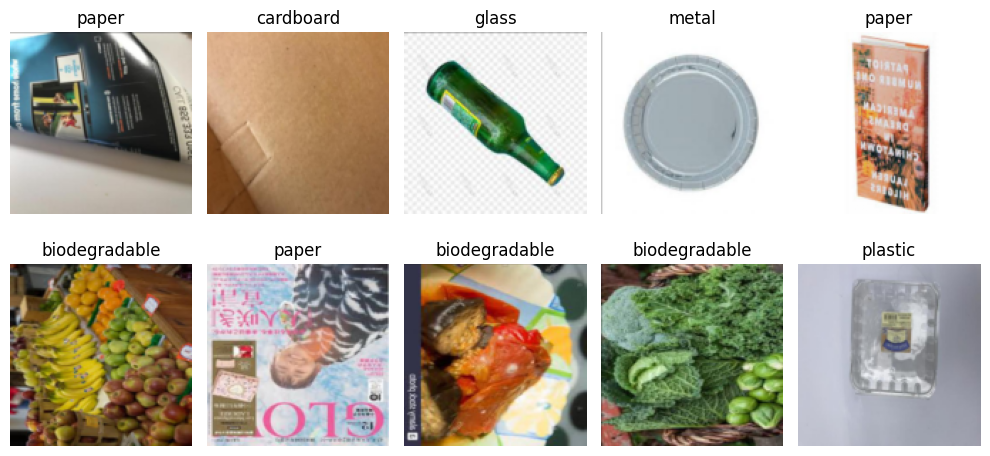

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import random

plt.figure(figsize=(10, 5))

for i in range(10):
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]

    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(train_dataset.idx_to_class[label]) # Use train_dataset.idx_to_class
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import torch
# The calculation of class_weights has been moved to the cell where the criterion is defined to ensure proper device assignment.

In [8]:
# The datasets are already correctly split by folder structure
# The random_split logic is no longer needed.

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 18649
Validation dataset size: 2113
Test dataset size: 2246


In [9]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_classes): # num_classes is now a parameter
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
import torch
import torch.nn as nn # Ensure nn is imported for CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes=num_classes).to(device) # Pass the correct num_classes

# Calculate class weights and move to device using labels from the correctly loaded train_dataset
labels = [label for _, label in train_dataset]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels), # This will now yield 6 unique classes (0-5)
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [11]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.3
)

In [12]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for epoch in range(10):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step(train_loss)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch 0, Loss: 800.5625, Accuracy: 51.28%
Epoch 1, Loss: 703.1846, Accuracy: 57.93%
Epoch 2, Loss: 733.1652, Accuracy: 57.12%
Epoch 3, Loss: 699.7916, Accuracy: 58.51%
Epoch 4, Loss: 708.9520, Accuracy: 57.34%
Epoch 5, Loss: 706.6742, Accuracy: 57.43%
Epoch 6, Loss: 634.1545, Accuracy: 61.89%
Epoch 7, Loss: 587.9538, Accuracy: 65.44%
Epoch 8, Loss: 589.9872, Accuracy: 65.20%
Epoch 9, Loss: 557.6518, Accuracy: 66.83%


In [13]:
if 'model' not in globals():
    raise NameError("The 'model' variable is not defined. Please ensure the preceding cells, especially the one initializing the model (e.g., cell Ptr6jUneEVVV), have been executed.")

model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 91.1667, Test Accuracy: 51.34%
